In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
earthquakes = pd.read_csv(
    "data/processed/earthquakes_processed.csv"
)

earthquakes.head()

,Time,Date,Year,Month,Day,Hour,Weekday,Latitude,Longitude,Depth_km,Magnitude,Location
0,2025-12-30 23:51:36.674000+00:00,2025-12-30,2025,12,30,23,Tuesday,39.4639,142.7562,35.000,4.8,"69 km E of Yamada, Japan"
1,2025-12-30 22:36:09.826000+00:00,2025-12-30,2025,12,30,22,Tuesday,3.0448,128.8654,10.000,4.5,"173 km NNE of Tobelo, Indonesia"
2,2025-12-30 22:25:43.819000+00:00,2025-12-30,2025,12,30,22,Tuesday,60.5503,-140.1190,5.000,3.3,"113 km N of Yakutat, Alaska"
3,2025-12-30 22:19:46.317000+00:00,2025-12-30,2025,12,30,22,Tuesday,39.5984,143.3045,27.735,4.8,"117 km E of Miyako, Japan"
4,2025-12-30 22:14:01.822000+00:00,2025-12-30,2025,12,30,22,Tuesday,62.7050,-149.2790,59.600,2.5,"51 km ENE of Chase, Alaska"


In [3]:
earthquakes["Time"] = pd.to_datetime(
    earthquakes["Time"],
    format="mixed",
    utc=True,
    errors="coerce"
)

earthquakes.head()

,Time,Date,Year,Month,Day,Hour,Weekday,Latitude,Longitude,Depth_km,Magnitude,Location
0,2025-12-30 23:51:36.674000+00:00,2025-12-30,2025,12,30,23,Tuesday,39.4639,142.7562,35.000,4.8,"69 km E of Yamada, Japan"
1,2025-12-30 22:36:09.826000+00:00,2025-12-30,2025,12,30,22,Tuesday,3.0448,128.8654,10.000,4.5,"173 km NNE of Tobelo, Indonesia"
2,2025-12-30 22:25:43.819000+00:00,2025-12-30,2025,12,30,22,Tuesday,60.5503,-140.1190,5.000,3.3,"113 km N of Yakutat, Alaska"
3,2025-12-30 22:19:46.317000+00:00,2025-12-30,2025,12,30,22,Tuesday,39.5984,143.3045,27.735,4.8,"117 km E of Miyako, Japan"
4,2025-12-30 22:14:01.822000+00:00,2025-12-30,2025,12,30,22,Tuesday,62.7050,-149.2790,59.600,2.5,"51 km ENE of Chase, Alaska"


In [4]:
earthquakes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   Time       20000 non-null  datetime64[ns, UTC]
 1   Date       20000 non-null  object             
 2   Year       20000 non-null  int64              
 3   Month      20000 non-null  int64              
 4   Day        20000 non-null  int64              
 5   Hour       20000 non-null  int64              
 6   Weekday    20000 non-null  object             
 7   Latitude   20000 non-null  float64            
 8   Longitude  20000 non-null  float64            
 9   Depth_km   20000 non-null  float64            
 10  Magnitude  20000 non-null  float64            
 11  Location   20000 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(4), int64(4), object(3)
memory usage: 1.8+ MB


In [5]:
earthquakes.describe()

,Year,Month,Day,Hour,Latitude,Longitude,Depth_km,Magnitude
count,20000.0,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,2025.0,8.501550,16.012000,11.477850,28.146457,2.097588,54.591497,3.949334
std,0.0,2.185781,9.044907,7.013242,31.139010,136.579214,100.523567,0.848348
min,2025.0,5.000000,1.000000,0.000000,-65.608800,-179.994400,-3.370000,2.500000
25%,2025.0,7.000000,8.000000,5.000000,7.359625,-139.753025,10.000000,3.100000
50%,2025.0,8.000000,16.000000,11.000000,39.669050,-27.886300,17.385500,4.200000
75%,2025.0,10.000000,24.000000,18.000000,52.330975,149.341850,51.548000,4.500000
max,2025.0,12.000000,31.000000,23.000000,87.081500,179.999400,669.556000,8.800000


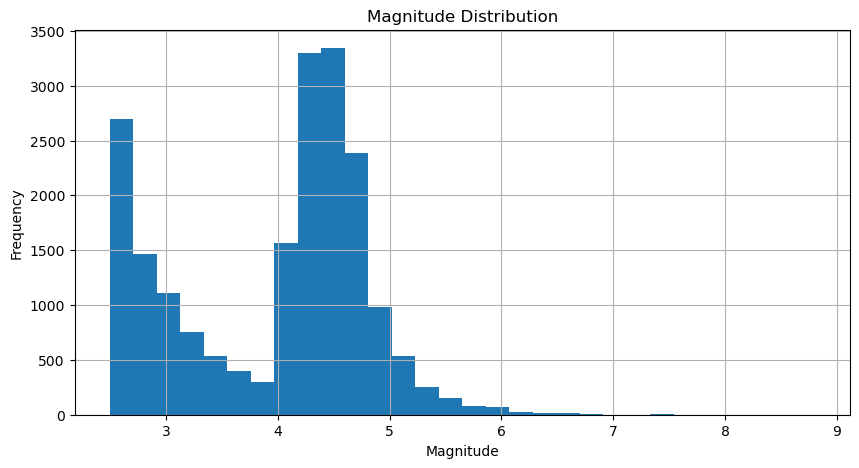

In [6]:
plt.figure(figsize=(10,5))

plt.hist(
    earthquakes["Magnitude"],
    bins=30
)

plt.title("Magnitude Distribution")

plt.xlabel("Magnitude")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

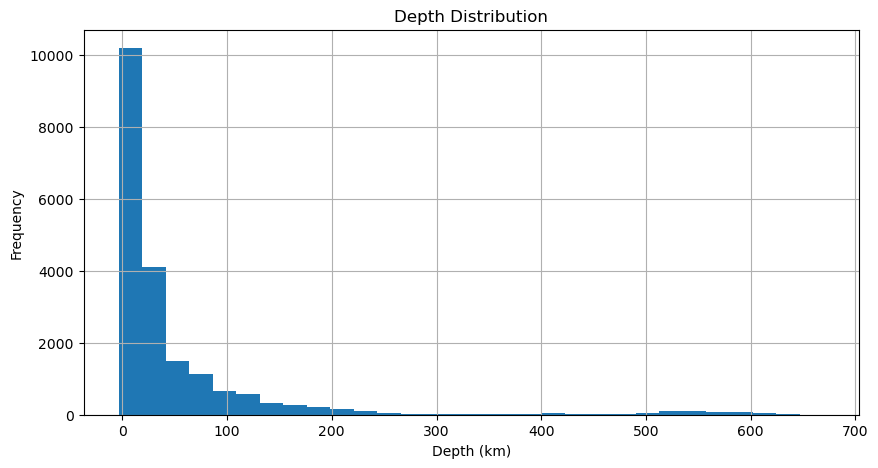

In [7]:
plt.figure(figsize=(10,5))

plt.hist(
    earthquakes["Depth_km"],
    bins=30
)

plt.title("Depth Distribution")

plt.xlabel("Depth (km)")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

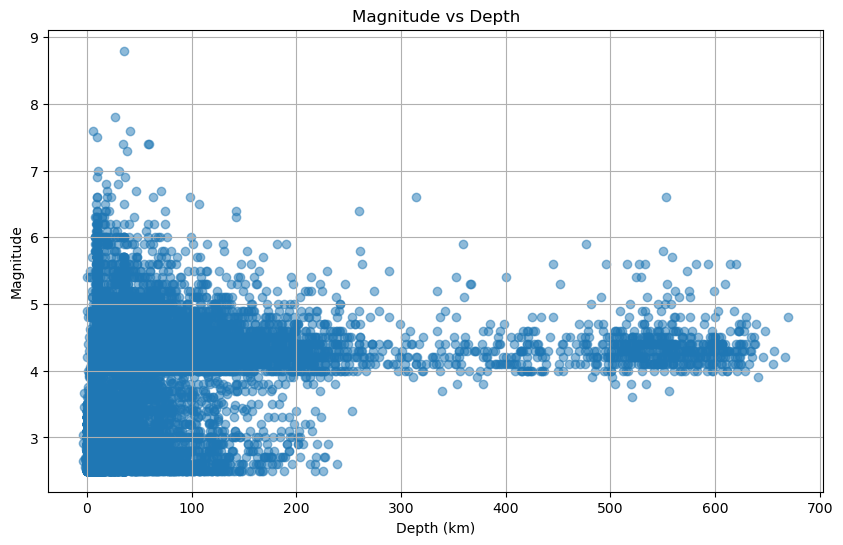

In [8]:
plt.figure(figsize=(10,6))

plt.scatter(
    earthquakes["Depth_km"],
    earthquakes["Magnitude"],
    alpha=0.5
)

plt.xlabel("Depth (km)")

plt.ylabel("Magnitude")

plt.title("Magnitude vs Depth")

plt.grid(True)

plt.show()

In [9]:
earthquakes["Month"] = earthquakes["Time"].dt.to_period("M")

monthly_counts = (
    earthquakes
    .groupby("Month")
    .size()
    .reset_index(name="Earthquake_Count")
)

monthly_counts

C:\Users\USER\AppData\Local\Temp\ipykernel_14004\3452122628.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  earthquakes["Month"] = earthquakes["Time"].dt.to_period("M")


,Month,Earthquake_Count
0,2025-05,1716
1,2025-06,2010
2,2025-07,4180
3,2025-08,3081
4,2025-09,2231
5,2025-10,2016
6,2025-11,1948
7,2025-12,2818


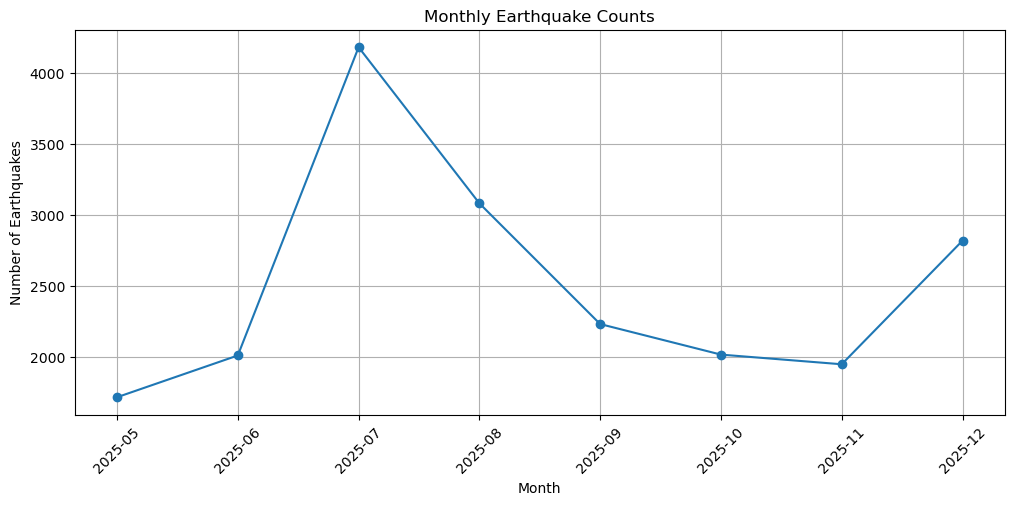

In [10]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_counts["Month"].astype(str),
    monthly_counts["Earthquake_Count"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Earthquake Counts")

plt.xlabel("Month")

plt.ylabel("Number of Earthquakes")

plt.grid(True)

plt.show()

In [11]:
largest = earthquakes.nlargest(
    20,
    "Magnitude"
)

largest[
    [
        "Time",
        "Location",
        "Magnitude",
        "Depth_km"
    ]
]

,Time,Location,Magnitude,Depth_km
13152,2025-07-29 23:24:52.483000+00:00,"2025 Kamchatka Peninsula, Russia Earthquake",8.8,35.000
7783,2025-09-18 18:58:14.939000+00:00,"140 km E of Petropavlovsk-Kamchatsky, Russia",7.8,27.000
1833,2025-12-08 14:15:09.896000+00:00,"2025 Aomori Prefecture, Japan Earthquake",7.6,40.720
6047,2025-10-10 20:29:20.075000+00:00,Drake Passage,7.6,5.639
9744,2025-08-22 02:16:18.246000+00:00,2025 Southern Drake Passage Earthquake,7.5,10.000
6161,2025-10-10 01:43:59.585000+00:00,"12 km E of Santiago, Philippines",7.4,59.425
8094,2025-09-13 02:37:56.761000+00:00,"105 km E of Petropavlovsk-Kamchatsky, Russia",7.4,58.000
14393,2025-07-20 06:49:04.327000+00:00,"2025 Eastern Kamchatka, Russia Earthquake",7.4,34.000
15204,2025-07-16 20:37:41.667000+00:00,"2025 Sand Point, Alaska Earthquake",7.3,38.000
2453,2025-12-06 20:41:49.288000+00:00,2025 Hubbard Glacier Earthquake,7.0,10.317


In [12]:
monthly_avg = (
    earthquakes
    .groupby("Month")["Magnitude"]
    .mean()
    .reset_index()
)

monthly_avg

,Month,Magnitude
0,2025-05,3.866562
1,2025-06,3.845597
2,2025-07,3.983163
3,2025-08,4.055370
4,2025-09,4.097409
5,2025-10,4.144132
6,2025-11,4.013299
7,2025-12,3.606812


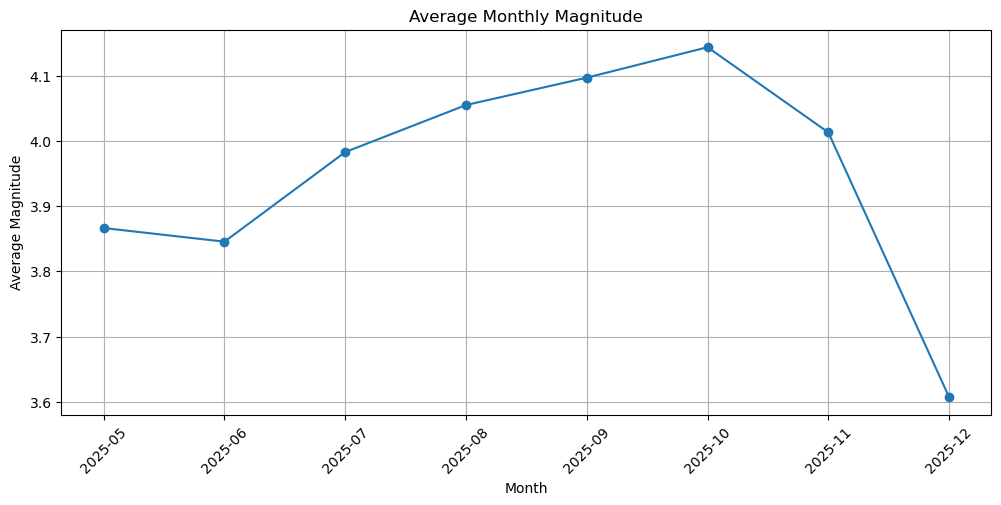

In [13]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_avg["Month"].astype(str),
    monthly_avg["Magnitude"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Average Monthly Magnitude")

plt.xlabel("Month")

plt.ylabel("Average Magnitude")

plt.grid(True)

plt.show()

In [14]:
monthly_counts.to_csv(
    "outputs/reports/monthly_earthquake_statistics.csv",
    index=False
)

monthly_avg.to_csv(
    "outputs/reports/monthly_average_magnitude.csv",
    index=False
)

print("Scientific analysis completed successfully.")

Scientific analysis completed successfully.
